In [1]:
from sklearn.ensemble import VotingClassifier, StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/train_clear.csv")

In [3]:
target = "Liver_Disease_Type"
X = df.drop(columns=[target])
y = df[target]

In [4]:
le = LabelEncoder()
y_encoded = np.array(le.fit_transform(y))

In [5]:
cat_cols = X.select_dtypes(include=['object', 'string']).columns

In [6]:
onehot_cat_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='passthrough' 
)

In [7]:
ordinal_cat_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=np.int64), cat_cols)
    ],
    remainder='passthrough' 
)

In [8]:
pipe_lr = Pipeline([
    ('ohe', onehot_cat_preprocessor),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression())
])

In [9]:
f"Точность логистической регрессии: {cross_val_score(pipe_lr, X, y_encoded, cv=5, scoring="accuracy").mean():.3f}"

'Точность логистической регрессии: 0.820'

In [10]:
pipe_bayes = Pipeline([
    ('ordinal', ordinal_cat_preprocessor),
    ('nb', GaussianNB())
])

In [11]:
f"Точность наивного байеса: {cross_val_score(pipe_bayes, X, y_encoded, cv=5, scoring="accuracy").mean():.3f}"

'Точность наивного байеса: 0.781'

In [12]:
pipe_xgb = Pipeline([
    ('ordinal', ordinal_cat_preprocessor),
    ('xgb', XGBClassifier())
])

In [13]:
f"Точность XGBoost: {cross_val_score(pipe_xgb, X, y_encoded, cv=5, scoring="accuracy").mean():.3f}"

'Точность XGBoost: 0.878'

In [14]:
estimators_list = [
    ('logreg', pipe_lr),
    ('nb', pipe_bayes),
    ('xgb', pipe_xgb)
]

In [15]:
voting_soft = VotingClassifier(estimators=estimators_list, voting='soft', n_jobs=-1)

In [16]:
scores_voting = cross_val_score(voting_soft, X, y_encoded, cv=5, scoring='accuracy')

In [17]:
print(f"Точность голосования: {scores_voting.mean():.3f} ± {scores_voting.std():.3f}")

Точность голосования: 0.850 ± 0.003


In [18]:
stacking = StackingClassifier(estimators=estimators_list, final_estimator=LogisticRegression(), cv=5, n_jobs=-1)

In [19]:
scores_stacking = cross_val_score(stacking, X, y_encoded, cv=5, scoring="accuracy")

In [20]:
print(f"Точность стека: {scores_stacking.mean():.3f} ± {scores_stacking.std():.3f}")

Точность стека: 0.878 ± 0.004


In [21]:
stacking.fit(X, y_encoded)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('logreg', ...), ('nb', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A

In [22]:
meta_model = stacking.final_estimator_
assert isinstance(meta_model, LogisticRegression)
class_names = le.classes_
base_names = [estimator[0] for estimator in estimators_list]

coefs = meta_model.coef_
n_classes = coefs.shape[0]
n_models = len(base_names)

coefs_reshaped = coefs.reshape(n_classes, n_models, n_classes)

model_importance = np.abs(coefs_reshaped).mean(axis=(0, 2))

importance_df = pd.DataFrame({
    'model': base_names,
    'avg_weight': model_importance
}).sort_values('avg_weight', ascending=False)

print("Итоговая важность базовых моделей:")
print(importance_df)

Итоговая важность базовых моделей:
    model  avg_weight
2     xgb    1.642591
0  logreg    0.992440
1      nb    0.481219


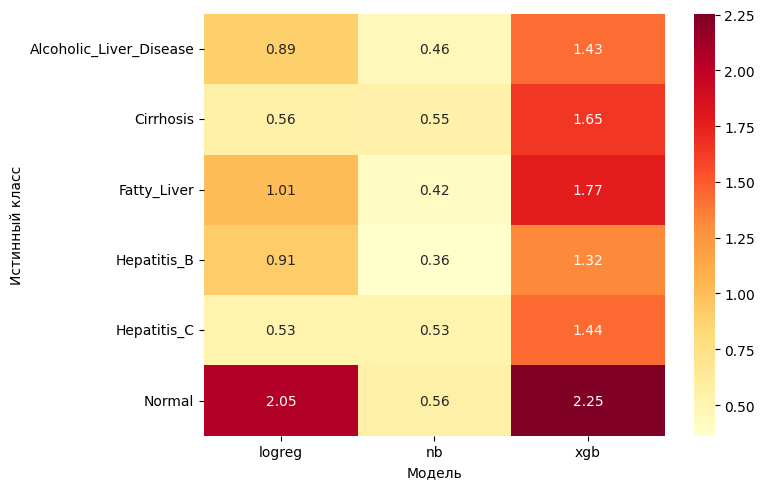

In [23]:
class_model_weights = np.abs(coefs_reshaped).mean(axis=2)

heatmap_df = pd.DataFrame(
    class_model_weights,
    index=le.classes_,
    columns=base_names
)

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='YlOrRd')
plt.ylabel('Истинный класс')
plt.xlabel('Модель')
plt.tight_layout()
plt.show()